# 1.2 audio_class_sim confidence 평가

## 실험 질문

`audio_class_sim = cosine(audio_emb, class_emb)`가 confidence와 얼마나 관련이 있는가?

이번 실험에서는 metadata의 `class` 값을 `data/class_embedding/{class}.npy`와 매핑한다.

예:

```text
metadata class = fx-o -> data/class_embedding/fx-o.npy
metadata class = sp-s -> data/class_embedding/sp-s.npy
```

모델 학습은 하지 않는다. audio embedding과 해당 class embedding의 cosine similarity만 사용한다.

## 평가 방식

### A. confidence별 similarity 분포 확인

1. Confidence별 Mean ± Std Plot
2. Confidence별 Boxplot

가설이 맞다면 confidence가 1 -> 5로 올라갈수록 `audio_class_sim` 분포도 위로 이동해야 한다.

### B. cosine similarity 5구간 분류 평가

`audio_class_sim`을 낮은 순서부터 5개 구간으로 나누고, 각 구간을 예측 confidence로 본다.

```text
가장 낮은 similarity 구간 -> predicted_confidence = 1
두 번째 구간              -> predicted_confidence = 2
세 번째 구간              -> predicted_confidence = 3
네 번째 구간              -> predicted_confidence = 4
가장 높은 similarity 구간 -> predicted_confidence = 5
```

그 다음 실제 confidence와 비교해서 다음을 본다.

- 각 predicted confidence 구간에 실제 confidence 1/2/3/4/5가 몇 개 들어갔는지
- Accuracy
- Precision
- Recall
- F1
- scikit-learn classification report

주의: 이건 학습 모델이 아니라 similarity를 단순 5등분한 rule-based classifier다.

모든 output은 `deft논문기반_실험/audio_class_sim_confidence_outputs/` 안에 저장한다.

In [11]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')

HERE = Path.cwd()
if (HERE / '실험계획.md').exists():
    EXP_DIR = HERE
    ROOT = HERE.parent
else:
    ROOT = HERE
    EXP_DIR = ROOT / 'deft논문기반_실험'

AUDIO_EMB_DIR = ROOT / 'data' / 'features' / 'clap_audio_embeddings'
CLASS_EMB_DIR = ROOT / 'data' / 'class_embedding'
META_CSV = ROOT / 'data' / 'metadata' / 'BSD10k_metadata.csv'

OUT_DIR = EXP_DIR / 'audio_class_sim_confidence_outputs'
PLOT_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# 빠른 smoke test가 필요하면 숫자를 넣는다. 전체 실험은 None.
SAMPLE_N = None
SEED = 42

LABELS = [1, 2, 3, 4, 5]

print('ROOT:', ROOT)
print('AUDIO_EMB_DIR:', AUDIO_EMB_DIR, AUDIO_EMB_DIR.exists())
print('CLASS_EMB_DIR:', CLASS_EMB_DIR, CLASS_EMB_DIR.exists())
print('META_CSV     :', META_CSV, META_CSV.exists())
print('OUT_DIR      :', OUT_DIR)

ROOT: c:\Users\solok\Desktop\Dcase baseline
AUDIO_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\features\clap_audio_embeddings True
CLASS_EMB_DIR: c:\Users\solok\Desktop\Dcase baseline\data\class_embedding True
META_CSV     : c:\Users\solok\Desktop\Dcase baseline\data\metadata\BSD10k_metadata.csv True
OUT_DIR      : c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs


## 1. 입력 데이터 구성

입력은 두 종류의 embedding이다.

- audio: `data/features/clap_audio_embeddings/{sound_id}.npy`
- class: `data/class_embedding/{class}.npy`

`BSD10k_metadata.csv`에서 `sound_id`, `class`, `confidence`를 읽고 다음처럼 매핑한다.

```text
sound_id -> audio embedding
class    -> class embedding
```

In [12]:
meta = pd.read_csv(META_CSV)
meta['confidence'] = pd.to_numeric(meta['confidence'], errors='coerce')
meta = meta[meta['confidence'].between(1, 5)].copy()
meta['confidence'] = meta['confidence'].astype(int)

audio_paths = {p.stem: p for p in AUDIO_EMB_DIR.glob('*.npy')}
class_paths = {p.stem: p for p in CLASS_EMB_DIR.glob('*.npy') if p.stem.startswith(('m-', 'is-', 'sp-', 'fx-', 'ss-'))}

df = meta[['sound_id', 'class', 'class_idx', 'class_top', 'confidence', 'title', 'tags', 'description']].copy()
df['sound_id_str'] = df['sound_id'].astype(str)
df['audio_emb_path'] = df['sound_id_str'].map(lambda x: str(audio_paths[x]) if x in audio_paths else None)
df['class_emb_path'] = df['class'].map(lambda x: str(class_paths[x]) if x in class_paths else None)

missing_audio = df['audio_emb_path'].isna().sum()
missing_class = df['class_emb_path'].isna().sum()
df = df.dropna(subset=['audio_emb_path', 'class_emb_path']).reset_index(drop=True)

if SAMPLE_N is not None:
    df = df.sample(n=min(SAMPLE_N, len(df)), random_state=SEED).reset_index(drop=True)

mapping_summary = pd.DataFrame([
    {'item': 'metadata rows with confidence', 'count': len(meta)},
    {'item': 'audio embedding files', 'count': len(audio_paths)},
    {'item': 'class embedding files', 'count': len(class_paths)},
    {'item': 'missing audio embeddings', 'count': int(missing_audio)},
    {'item': 'missing class embeddings', 'count': int(missing_class)},
    {'item': 'usable rows', 'count': len(df)},
])

mapping_summary.to_csv(OUT_DIR / 'mapping_summary.csv', index=False, encoding='utf-8-sig')
display(mapping_summary)
display(df[['sound_id', 'class', 'confidence', 'audio_emb_path', 'class_emb_path']].head())
display(df['confidence'].value_counts().sort_index().rename('count').to_frame())

missing_classes = sorted(set(meta['class']) - set(class_paths))
print('missing class embedding labels:', missing_classes)

,item,count
0,metadata rows with confidence,10956
1,audio embedding files,10956
2,class embedding files,23
3,missing audio embeddings,0
4,missing class embeddings,0
5,usable rows,10956


,sound_id,class,confidence,audio_emb_path,class_emb_path
0,185755,fx-o,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
1,358405,is-w,5,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
2,358760,is-w,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
3,432206,fx-o,4,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...
4,80630,sp-s,5,c:\Users\solok\Desktop\Dcase baseline\data\fea...,c:\Users\solok\Desktop\Dcase baseline\data\cla...


,count
confidence,
1,106
2,749
3,3280
4,6045
5,776


missing class embedding labels: []


## 2. audio_class_sim 계산

각 sample의 audio embedding과 해당 metadata class embedding의 cosine similarity를 계산한다.

In [13]:
class_embedding_cache = {}

def load_vector(path):
    return np.load(path).astype(np.float32).reshape(-1)

def get_class_embedding(path):
    if path not in class_embedding_cache:
        class_embedding_cache[path] = load_vector(path)
    return class_embedding_cache[path]

def cosine(audio_path, class_path):
    audio_emb = load_vector(audio_path)
    class_emb = get_class_embedding(class_path)
    denom = float(np.linalg.norm(audio_emb) * np.linalg.norm(class_emb))
    if denom == 0.0:
        return np.nan
    return float(np.dot(audio_emb, class_emb) / denom)

sims = []
failed = []

for row in df.to_dict('records'):
    try:
        sims.append(cosine(row['audio_emb_path'], row['class_emb_path']))
    except Exception as exc:
        sims.append(np.nan)
        failed.append({'sound_id': row['sound_id'], 'class': row['class'], 'error': str(exc)})

df['audio_class_sim'] = sims
df = df.dropna(subset=['audio_class_sim']).reset_index(drop=True)

if failed:
    pd.DataFrame(failed).to_csv(OUT_DIR / 'failed_similarity_rows.csv', index=False, encoding='utf-8-sig')

print('usable rows:', len(df))
print('failed rows:', len(failed))
display(df[['sound_id', 'class', 'confidence', 'audio_class_sim']].head())

usable rows: 10956
failed rows: 0


,sound_id,class,confidence,audio_class_sim
0,185755,fx-o,4,0.206392
1,358405,is-w,5,0.105113
2,358760,is-w,4,-0.063060
3,432206,fx-o,4,-0.160971
4,80630,sp-s,5,0.203966


## 3. Confidence별 Mean ± Std와 Boxplot

실제 confidence label별로 `audio_class_sim` 분포가 어떻게 움직이는지 본다.

,confidence,n,mean,std,median,q1,q3
0,1,106,0.0377,0.1317,0.0374,-0.0492,0.1258
1,2,749,0.0661,0.1331,0.0668,-0.0214,0.1609
2,3,3280,0.0744,0.1320,0.0741,-0.0192,0.1624
3,4,6045,0.0780,0.1306,0.0750,-0.0127,0.1674
4,5,776,0.1331,0.1353,0.1142,0.0436,0.2342


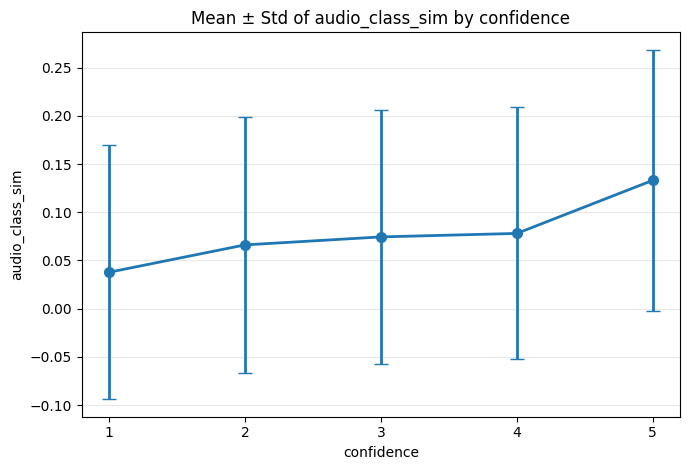

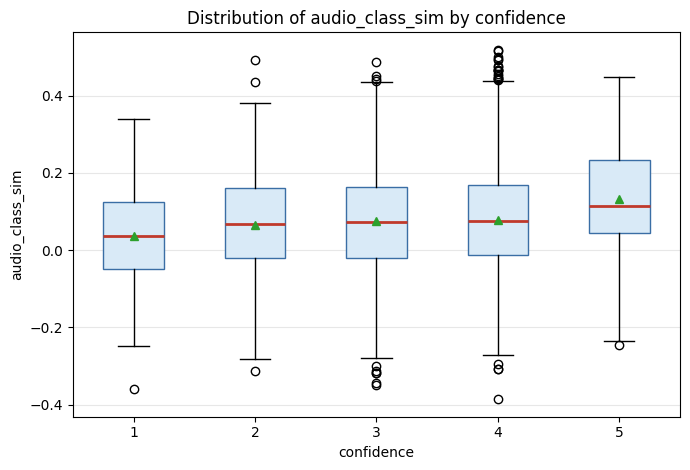

In [14]:
confidence_stats = df.groupby('confidence').agg(
    n=('audio_class_sim', 'size'),
    mean=('audio_class_sim', 'mean'),
    std=('audio_class_sim', 'std'),
    median=('audio_class_sim', 'median'),
    q1=('audio_class_sim', lambda s: s.quantile(0.25)),
    q3=('audio_class_sim', lambda s: s.quantile(0.75)),
).reset_index()

confidence_stats.to_csv(OUT_DIR / 'confidence_mean_std.csv', index=False, encoding='utf-8-sig')
display(confidence_stats.round(4))

fig, ax = plt.subplots(figsize=(7, 4.8))
ax.errorbar(
    confidence_stats['confidence'],
    confidence_stats['mean'],
    yerr=confidence_stats['std'],
    fmt='o-',
    capsize=5,
    linewidth=2,
    markersize=7,
)
ax.set_title('Mean ± Std of audio_class_sim by confidence')
ax.set_xlabel('confidence')
ax.set_ylabel('audio_class_sim')
ax.set_xticks(LABELS)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_mean_std_audio_class_sim.png', dpi=200)
plt.show()

plot_data = [df.loc[df['confidence'] == c, 'audio_class_sim'].values for c in LABELS]
fig, ax = plt.subplots(figsize=(7, 4.8))
box = ax.boxplot(plot_data, labels=LABELS, showmeans=True, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('#D9EAF7')
    patch.set_edgecolor('#3A6EA5')
for median in box['medians']:
    median.set_color('#C0392B')
    median.set_linewidth(2)
ax.set_title('Distribution of audio_class_sim by confidence')
ax.set_xlabel('confidence')
ax.set_ylabel('audio_class_sim')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'confidence_boxplot_audio_class_sim.png', dpi=200)
plt.show()

## 4. Cosine similarity 5구간 분류

`audio_class_sim`을 낮은 값부터 높은 값까지 5개 분위수 구간으로 나눈다.

각 구간을 예측 confidence 1-5로 매핑한다.

```text
Q1_lowest  -> predicted_confidence = 1
Q2         -> predicted_confidence = 2
Q3         -> predicted_confidence = 3
Q4         -> predicted_confidence = 4
Q5_highest -> predicted_confidence = 5
```

In [15]:
bin_labels = ['Q1_pred_1', 'Q2_pred_2', 'Q3_pred_3', 'Q4_pred_4', 'Q5_pred_5']
df['sim_bin'] = pd.qcut(
    df['audio_class_sim'],
    q=5,
    labels=bin_labels,
    duplicates='drop',
)

bin_to_pred = {label: idx + 1 for idx, label in enumerate(bin_labels)}
df['pred_confidence_from_sim'] = df['sim_bin'].map(bin_to_pred).astype(int)

bin_ranges = df.groupby('sim_bin', observed=True).agg(
    predicted_confidence=('pred_confidence_from_sim', 'first'),
    n=('sound_id', 'count'),
    sim_min=('audio_class_sim', 'min'),
    sim_mean=('audio_class_sim', 'mean'),
    sim_max=('audio_class_sim', 'max'),
).reset_index()

df.to_csv(OUT_DIR / 'audio_class_similarity_with_bin_predictions.csv', index=False, encoding='utf-8-sig')
bin_ranges.to_csv(OUT_DIR / 'similarity_bin_ranges.csv', index=False, encoding='utf-8-sig')

display(bin_ranges.round(4))
display(df[['sound_id', 'class', 'confidence', 'audio_class_sim', 'sim_bin', 'pred_confidence_from_sim']].head())

,sim_bin,predicted_confidence,n,sim_min,sim_mean,sim_max
0,Q1_pred_1,1,2192,-0.3858,-0.1046,-0.0344
1,Q2_pred_2,2,2191,-0.0344,0.0075,0.0446
2,Q3_pred_3,3,2191,0.0446,0.0778,0.1107
3,Q4_pred_4,4,2191,0.1108,0.1494,0.1927
4,Q5_pred_5,5,2191,0.1927,0.2681,0.5185


,sound_id,class,confidence,audio_class_sim,sim_bin,pred_confidence_from_sim
0,185755,fx-o,4,0.206392,Q5_pred_5,5
1,358405,is-w,5,0.105113,Q3_pred_3,3
2,358760,is-w,4,-0.063060,Q1_pred_1,1
3,432206,fx-o,4,-0.160971,Q1_pred_1,1
4,80630,sp-s,5,0.203966,Q5_pred_5,5


## 5. 구간별 실제 confidence 개수

아래 표는 similarity 기반으로 `1,2,3,4,5`라고 예측한 각 구간에 실제 confidence 데이터가 몇 개씩 들어갔는지를 보여준다.

행: similarity 기반 predicted confidence

열: 실제 confidence

In [16]:
count_table = pd.crosstab(
    df['pred_confidence_from_sim'],
    df['confidence'],
    rownames=['predicted_by_similarity'],
    colnames=['true_confidence'],
).reindex(index=LABELS, columns=LABELS, fill_value=0)

ratio_table = pd.crosstab(
    df['pred_confidence_from_sim'],
    df['confidence'],
    normalize='index',
    rownames=['predicted_by_similarity'],
    colnames=['true_confidence'],
).reindex(index=LABELS, columns=LABELS, fill_value=0)

count_table.to_csv(OUT_DIR / 'similarity_bin_true_confidence_counts.csv', encoding='utf-8-sig')
ratio_table.to_csv(OUT_DIR / 'similarity_bin_true_confidence_ratios.csv', encoding='utf-8-sig')

print('Counts: predicted confidence by similarity bin vs true confidence')
display(count_table)
print('Ratios within each predicted bin')
display(ratio_table.round(4))

Counts: predicted confidence by similarity bin vs true confidence


true_confidence,1,2,3,4,5
predicted_by_similarity,,,,,
1,31,168,712,1206,75
2,24,154,640,1250,123
3,19,138,652,1200,182
4,20,154,666,1213,138
5,12,135,610,1176,258


Ratios within each predicted bin


true_confidence,1,2,3,4,5
predicted_by_similarity,,,,,
1,0.0141,0.0766,0.3248,0.5502,0.0342
2,0.0110,0.0703,0.2921,0.5705,0.0561
3,0.0087,0.0630,0.2976,0.5477,0.0831
4,0.0091,0.0703,0.3040,0.5536,0.0630
5,0.0055,0.0616,0.2784,0.5367,0.1178


## 6. Accuracy / Precision / Recall / F1

similarity 5구간을 confidence 1-5 예측값으로 간주하고 실제 confidence와 비교한다.

- Accuracy: 전체 중 예측 confidence가 실제 confidence와 정확히 같은 비율
- Precision: 특정 confidence로 예측한 것 중 실제로 그 confidence인 비율
- Recall: 실제 특정 confidence 중 그 confidence로 맞게 예측한 비율
- F1: precision과 recall의 조화 평균

confidence 분포가 불균형하므로 macro 평균과 weighted 평균을 같이 본다.

In [17]:
y_true = df['confidence'].astype(int)
y_pred = df['pred_confidence_from_sim'].astype(int)

accuracy = accuracy_score(y_true, y_pred)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=LABELS, average='macro', zero_division=0
)
weighted_p, weighted_r, weighted_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, labels=LABELS, average='weighted', zero_division=0
)

metric_summary = pd.DataFrame([
    {
        'method': 'audio_class_sim_quantile_5bin',
        'accuracy': accuracy,
        'macro_precision': macro_p,
        'macro_recall': macro_r,
        'macro_f1': macro_f1,
        'weighted_precision': weighted_p,
        'weighted_recall': weighted_r,
        'weighted_f1': weighted_f1,
    }
])

metric_summary.to_csv(OUT_DIR / 'similarity_5bin_metrics.csv', index=False, encoding='utf-8-sig')
display(metric_summary.round(4))

,method,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,audio_class_sim_quantile_5bin,0.2107,0.2107,0.246,0.1677,0.4078,0.2107,0.2536


## 7. Confusion Matrix와 Classification Report

In [18]:
cm = pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=LABELS),
    index=[f'true_{x}' for x in LABELS],
    columns=[f'pred_{x}' for x in LABELS],
)
cm.to_csv(OUT_DIR / 'similarity_5bin_confusion_matrix.csv', encoding='utf-8-sig')
display(cm)

report_text = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    zero_division=0,
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=LABELS,
    target_names=[f'confidence_{x}' for x in LABELS],
    output_dict=True,
    zero_division=0,
)

(OUT_DIR / 'similarity_5bin_classification_report.txt').write_text(report_text, encoding='utf-8')
pd.DataFrame(report_dict).T.to_csv(OUT_DIR / 'similarity_5bin_classification_report.csv', encoding='utf-8-sig')

print(report_text)

,pred_1,pred_2,pred_3,pred_4,pred_5
true_1,31,24,19,20,12
true_2,168,154,138,154,135
true_3,712,640,652,666,610
true_4,1206,1250,1200,1213,1176
true_5,75,123,182,138,258


              precision    recall  f1-score   support

confidence_1       0.01      0.29      0.03       106
confidence_2       0.07      0.21      0.10       749
confidence_3       0.30      0.20      0.24      3280
confidence_4       0.55      0.20      0.29      6045
confidence_5       0.12      0.33      0.17       776

    accuracy                           0.21     10956
   macro avg       0.21      0.25      0.17     10956
weighted avg       0.41      0.21      0.25     10956



## 8. Summary metrics 생성

실험 전체를 한 줄로 요약하는 `summary_metrics`를 만든다.

여기에는 confidence별 평균 증가 여부, confidence 5와 confidence 1/4의 평균 차이, similarity 5-bin 분류 성능을 함께 저장한다.

In [19]:
means = confidence_stats.set_index('confidence')['mean']
is_mean_monotonic_increasing = bool((means.diff().dropna() >= 0).all())

summary_metrics = pd.DataFrame([
    {
        'n_rows': int(len(df)),
        'is_mean_monotonic_increasing': is_mean_monotonic_increasing,
        'confidence_5_mean_minus_confidence_1_mean': float(means.loc[5] - means.loc[1]),
        'confidence_5_mean_minus_confidence_4_mean': float(means.loc[5] - means.loc[4]),
        'similarity_5bin_accuracy': float(accuracy),
        'similarity_5bin_macro_precision': float(macro_p),
        'similarity_5bin_macro_recall': float(macro_r),
        'similarity_5bin_macro_f1': float(macro_f1),
        'similarity_5bin_weighted_precision': float(weighted_p),
        'similarity_5bin_weighted_recall': float(weighted_r),
        'similarity_5bin_weighted_f1': float(weighted_f1),
    }
])

summary_metrics.to_csv(OUT_DIR / 'summary_metrics.csv', index=False, encoding='utf-8-sig')
display(summary_metrics.round(4))

,n_rows,is_mean_monotonic_increasing,confidence_5_mean_minus_confidence_1_mean,confidence_5_mean_minus_confidence_4_mean,similarity_5bin_accuracy,similarity_5bin_macro_precision,similarity_5bin_macro_recall,similarity_5bin_macro_f1,similarity_5bin_weighted_precision,similarity_5bin_weighted_recall,similarity_5bin_weighted_f1
0,10956,True,0.0953,0.055,0.2107,0.2107,0.246,0.1677,0.4078,0.2107,0.2536


## 9. 리포트 저장

In [20]:
summary = summary_metrics.iloc[0].to_dict()
summary['output_dir'] = str(OUT_DIR)

report_lines = []
report_lines.append('# audio_class_sim confidence 평가 결과')
report_lines.append('')
report_lines.append('## Class embedding mapping')
report_lines.append('metadata의 class 값을 data/class_embedding/{class}.npy와 매핑했다.')
report_lines.append('')
def table_text(table, index=False):
    return table.round(4).to_string(index=index)

report_lines.append('## Confidence별 Mean ± Std')
report_lines.append('```text')
report_lines.append(table_text(confidence_stats, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Summary metrics')
report_lines.append('```text')
report_lines.append(table_text(summary_metrics, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Similarity 5-bin ranges')
report_lines.append('```text')
report_lines.append(table_text(bin_ranges, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Similarity 5-bin true confidence counts')
report_lines.append('```text')
report_lines.append(table_text(count_table, index=True))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Similarity 5-bin metrics')
report_lines.append('```text')
report_lines.append(table_text(metric_summary, index=False))
report_lines.append('```')
report_lines.append('')
report_lines.append('## Classification report')
report_lines.append('```text')
report_lines.append(report_text)
report_lines.append('```')
report_lines.append('')
report_lines.append('## 저장된 그림')
report_lines.append('- plots/confidence_mean_std_audio_class_sim.png')
report_lines.append('- plots/confidence_boxplot_audio_class_sim.png')

(OUT_DIR / 'summary.json').write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding='utf-8')
(OUT_DIR / 'audio_class_sim_confidence_report.md').write_text('\n'.join(report_lines), encoding='utf-8')

print('saved:', OUT_DIR / 'audio_class_sim_confidence_report.md')
print('saved:', OUT_DIR / 'summary.json')

saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\audio_class_sim_confidence_report.md
saved: c:\Users\solok\Desktop\Dcase baseline\deft논문기반_실험\audio_class_sim_confidence_outputs\summary.json
